# Count (Cell Type, Tissue) Co-occurrences in CellxGene

This notebook counts how many cells of each type appear in each tissue across the CellxGene v2 corpus.

**Strategy:**
1. Load metadata parquet with per-file cell type and tissue counts
2. Map all CellxGene tissues to curated 81-tissue vocabulary using TissueEncoder logic
3. For files with single tissue: use aggregated counts directly
4. For files with multiple tissues: load actual chunks to get per-tissue breakdowns
5. Output: `Dict[curated_tissue, Dict[cell_type, count]]`

**Tissue Mapping:** Uses three-tier fallback strategy from `tissue_encoder.py`:
- Tier 1: Direct match in curated CZ slim list (81 tissues)
- Tier 2: Find nearest CZ slim ancestor via UBERON ontology
- Tier 3: Manual fallback mappings

**Note:** Each file UUID may have multiple chunks (e.g., `UUID_csr_chunk_0000_of_0003.h5ad`)

In [41]:
import pandas as pd
import json
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
import anndata as ad
import sys

# Add core module to path
sys.path.insert(0, '/data/batch-jobs')

from core.embeddings.tissue_encoder import TissueEncoder

## 1. Initialize Tissue Encoder and Build Mapping

In [42]:
# Initialize tissue encoder
print("Initializing TissueEncoder...")
tissue_encoder = TissueEncoder()

print(f"\nCurated vocabulary:")
print(f"  Tissues: {tissue_encoder.tissue_dim}")
print(f"  Organs: {tissue_encoder.organ_dim}")
print(f"  Systems: {tissue_encoder.system_dim}")
print(f"  Total encoding dim: {tissue_encoder.total_dim}")

Initializing TissueEncoder...

Curated vocabulary:
  Tissues: 81
  Organs: 28
  Systems: 17
  Total encoding dim: 126


In [43]:
# Create reverse mapping: tissue_id -> curated tissue name
idx_to_tissue = {idx: tissue_id for tissue_id, idx in tissue_encoder.tissue_to_idx.items()}

# Show sample curated tissues
print("Sample curated tissues:")
for i, tissue_id in enumerate(sorted(tissue_encoder.tissue_to_idx.keys())[:10]):
    label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
    print(f"  {tissue_id}: {label}")

Sample curated tissues:
  UBERON:0000004: nose
  UBERON:0000010: peripheral nervous system
  UBERON:0000014: zone of skin
  UBERON:0000029: lymph node
  UBERON:0000030: lamina propria
  UBERON:0000056: ureter
  UBERON:0000057: urethra
  UBERON:0000059: large intestine
  UBERON:0000160: intestine
  UBERON:0000175: pleural effusion


In [44]:
def map_tissue_to_curated(tissue_id: str, tissue_encoder: TissueEncoder) -> str:
    """
    Map any tissue ID to valid tissue vocabulary using TissueEncoder's strategy.
    
    Valid tissues include:
    - 81 curated CZ slim tissues
    - Additional tissues in FALLBACK_TISSUE_MAPPINGS (even if they map to themselves)
    
    Tier 1: Direct match in curated list
    Tier 2: Find nearest curated ancestor via ontology
    Tier 3: Use manual fallback mapping (may map to itself as a valid tissue)
    
    Args:
        tissue_id: Original tissue ontology term ID
        tissue_encoder: Initialized TissueEncoder instance
    
    Returns:
        Valid tissue ID (UBERON term) or None if no mapping found
    """
    curated_tissues_set = set(tissue_encoder.tissue_to_idx.keys())
    
    # Tier 1: Direct match in curated list
    if tissue_id in curated_tissues_set:
        return tissue_id
    
    # Tier 2: Find curated ancestor
    try:
        ancestors = tissue_encoder.ontology_parser.get_term_ancestors(tissue_id, include_self=False)
        for ancestor in ancestors:
            if ancestor in curated_tissues_set:
                return ancestor
    except:
        pass
    
    # Tier 3: Manual fallback mapping
    from core.embeddings.tissue_encoder import FALLBACK_TISSUE_MAPPINGS
    
    if tissue_id in FALLBACK_TISSUE_MAPPINGS:
        mapping = FALLBACK_TISSUE_MAPPINGS[tissue_id]
        mapped_tissue = mapping['tissue']
        
        # Return the mapped tissue (even if it maps to itself)
        # This extends our vocabulary beyond the 81 curated tissues
        return mapped_tissue
    
    # No mapping found
    return None


# Test mapping on some example tissues
test_tissues = [
    "UBERON:0002097",  # skin of body (should be direct)
    "UBERON:0000178",  # blood (should be direct)
    "CL:0000084",      # T cell (should map to blood via fallback)
    "UBERON:0000403",  # scalp (should map to itself via fallback)
    "UBERON:8480009",  # tendon (should map to itself via fallback)
]

print("\nTest tissue mappings:")
for tissue_id in test_tissues:
    try:
        original_label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
    except:
        original_label = tissue_id
    
    mapped = map_tissue_to_curated(tissue_id, tissue_encoder)
    if mapped:
        try:
            mapped_label = tissue_encoder.ontology_parser.get_term_label(mapped)
        except:
            mapped_label = mapped
        print(f"  {tissue_id} ({original_label})")
        print(f"    -> {mapped} ({mapped_label})")
    else:
        print(f"  {tissue_id} ({original_label}) -> NO MAPPING")


Test tissue mappings:
  UBERON:0002097 (skin of body)
    -> UBERON:0002097 (skin of body)
  UBERON:0000178 (blood)
    -> UBERON:0000178 (blood)
  CL:0000084 (T cell)
    -> UBERON:0000178 (blood)
  UBERON:0000403 (scalp)
    -> UBERON:0000403 (scalp)
  UBERON:8480009 (tendon of semitendinosus)
    -> UBERON:8480009 (tendon of semitendinosus)


## 2. Load Metadata and Identify Single-Tissue Files

In [45]:
# Load metadata
metadata_path = "/data/GenePT-tools/data/cellxgene_v2_metadata_v3.parquet"
df = pd.read_parquet(metadata_path)

print(f"Total files: {len(df)}")
print(f"Total cells: {df['cell_count'].sum():,}")
print(f"\nColumns: {df.columns.tolist()}")

Total files: 961
Total cells: 90,186,053

Columns: ['file_size', 'main_groups', 'cell_count', 'gene_count', 'obs_contents', 'var_contents', 'x_storage', 'embeddings', 'pairwise_relationships', 'expression_layers', 'obs_counts', 'filename']


In [46]:
# Helper function to parse JSON strings in obs_counts
def parse_obs_counts(obs_counts_dict, key):
    """
    Parse obs_counts dict to get counts for a specific key.
    
    Args:
        obs_counts_dict: dict with keys like 'tissue', 'cell_type'
        key: which key to extract (e.g., 'tissue', 'cell_type')
    
    Returns:
        dict mapping values to counts
    """
    if key not in obs_counts_dict:
        return {}
    
    json_str = obs_counts_dict[key]
    return json.loads(json_str)

# Test on first row
sample = df.iloc[0]
tissue_counts = parse_obs_counts(sample['obs_counts'], 'tissue_ontology_term_id')
cell_type_counts = parse_obs_counts(sample['obs_counts'], 'cell_type')

print(f"Sample file: {Path(sample['filename']).name}")
print(f"Tissue IDs: {tissue_counts}")
print(f"Cell types (first 5): {dict(list(cell_type_counts.items())[:5])}")

Sample file: 0041b9c3-6a49-4bf7-8514-9bc7190067a7
Tissue IDs: {'UBERON:0002097': 9424}
Cell types (first 5): {'CD4-positive helper T cell': 59, 'CD4-positive, alpha-beta memory T cell': 339, 'CD8-positive, alpha-beta cytotoxic T cell': 129, 'CD8-positive, alpha-beta memory T cell': 857, 'Langerhans cell': 36}


In [47]:
# Identify single-tissue vs multi-tissue files (after mapping to curated)
single_tissue_files = []
multi_tissue_files = []
unmapped_tissues = set()
unmapped_tissue_cell_counts = defaultdict(int)  # Track how many cells have unmapped tissues

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying files"):
    tissue_counts = parse_obs_counts(row['obs_counts'], 'tissue_ontology_term_id')
    uuid = Path(row['filename']).stem
    
    # Map all tissues to curated vocabulary
    mapped_tissue_counts = defaultdict(int)
    for tissue_id, count in tissue_counts.items():
        curated_tissue = map_tissue_to_curated(tissue_id, tissue_encoder)
        if curated_tissue:
            mapped_tissue_counts[curated_tissue] += count
        else:
            unmapped_tissues.add(tissue_id)
            unmapped_tissue_cell_counts[tissue_id] += count
    
    if len(mapped_tissue_counts) == 1:
        # Single tissue after mapping
        single_tissue_files.append({
            'uuid': uuid,
            'tissue': list(mapped_tissue_counts.keys())[0],
            'cell_type_counts': parse_obs_counts(row['obs_counts'], 'cell_type'),
            'total_cells': row['cell_count']
        })
    elif len(mapped_tissue_counts) > 1:
        # Multiple tissues after mapping
        multi_tissue_files.append({
            'uuid': uuid,
            'tissue_counts': dict(mapped_tissue_counts),
            'total_cells': row['cell_count']
        })
    # else: all tissues unmapped, skip this file

print(f"\nSingle-tissue files (after mapping): {len(single_tissue_files)}")
print(f"Multi-tissue files (after mapping): {len(multi_tissue_files)}")
print(f"Cells in single-tissue files: {sum(f['total_cells'] for f in single_tissue_files):,}")
print(f"Cells in multi-tissue files: {sum(f['total_cells'] for f in multi_tissue_files):,}")
print(f"\nUnmapped tissues: {len(unmapped_tissues)}")
print(f"Cells with unmapped tissues: {sum(unmapped_tissue_cell_counts.values()):,}")
if unmapped_tissues:
    print("\nTop unmapped tissues by cell count:")
    for tissue_id, count in sorted(unmapped_tissue_cell_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
        try:
            label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
            print(f"  {tissue_id}: {label:50s} ({count:>10,} cells)")
        except:
            print(f"  {tissue_id:50s} ({count:>10,} cells)")

Classifying files:   0%|          | 0/961 [00:00<?, ?it/s]


Single-tissue files (after mapping): 727
Multi-tissue files (after mapping): 226
Cells in single-tissue files: 52,769,044
Cells in multi-tissue files: 37,265,734

Unmapped tissues: 3
Cells with unmapped tissues: 165,172

Top unmapped tissues by cell count:
  CL:0000307: tracheal epithelial cell                           (   151,275 cells)
  UBERON:0000974: neck                                               (    13,751 cells)
  UBERON:0003072: optic cup                                          (       146 cells)


In [48]:
# Investigate unmapped tissues in detail
from core.embeddings.tissue_encoder import FALLBACK_TISSUE_MAPPINGS

print("=" * 80)
print("UNMAPPED TISSUE ANALYSIS")
print("=" * 80)

if unmapped_tissues:
    print(f"\nTotal unmapped tissues: {len(unmapped_tissues)}")
    print(f"Total cells affected: {sum(unmapped_tissue_cell_counts.values()):,}\n")
    
    # Check which unmapped tissues are in FALLBACK_TISSUE_MAPPINGS
    in_fallback = []
    not_in_fallback = []
    
    for tissue_id in unmapped_tissues:
        if tissue_id in FALLBACK_TISSUE_MAPPINGS:
            in_fallback.append(tissue_id)
        else:
            not_in_fallback.append(tissue_id)
    
    print(f"Unmapped tissues IN FALLBACK_TISSUE_MAPPINGS: {len(in_fallback)}")
    if in_fallback:
        print("  (These should have mapped - potential bug?)")
        for tissue_id in sorted(in_fallback)[:5]:
            fallback = FALLBACK_TISSUE_MAPPINGS[tissue_id]
            try:
                label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
            except:
                label = tissue_id
            print(f"    {tissue_id} ({label})")
            print(f"      -> maps to: {fallback['tissue']}")
    
    print(f"\nUnmapped tissues NOT IN FALLBACK_TISSUE_MAPPINGS: {len(not_in_fallback)}")
    if not_in_fallback:
        print("  (These need manual mappings added)")
        # Sort by cell count
        not_in_fallback_sorted = sorted(
            not_in_fallback, 
            key=lambda t: unmapped_tissue_cell_counts[t], 
            reverse=True
        )
        print("\n  Top 15 by cell count:")
        for tissue_id in not_in_fallback_sorted[:15]:
            try:
                label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
            except:
                label = "???"
            cell_count = unmapped_tissue_cell_counts[tissue_id]
            
            # Try to find ancestors
            try:
                ancestors = tissue_encoder.ontology_parser.get_term_ancestors(tissue_id, include_self=False)
                ancestor_labels = []
                for anc in ancestors[:3]:  # Show first 3 ancestors
                    try:
                        anc_label = tissue_encoder.ontology_parser.get_term_label(anc)
                        ancestor_labels.append(f"{anc} ({anc_label})")
                    except:
                        ancestor_labels.append(anc)
                ancestor_str = " <- ".join(ancestor_labels) if ancestor_labels else "No ancestors"
            except:
                ancestor_str = "Ontology lookup failed"
            
            print(f"\n    {tissue_id}: {label}")
            print(f"      Cells: {cell_count:,}")
            print(f"      Ancestors: {ancestor_str}")
else:
    print("\nNo unmapped tissues - all tissues successfully mapped!")

UNMAPPED TISSUE ANALYSIS

Total unmapped tissues: 3
Total cells affected: 165,172

Unmapped tissues IN FALLBACK_TISSUE_MAPPINGS: 0

Unmapped tissues NOT IN FALLBACK_TISSUE_MAPPINGS: 3
  (These need manual mappings added)

  Top 15 by cell count:

    CL:0000307: tracheal epithelial cell
      Cells: 151,275
      Ancestors: CL:0002202 (epithelial cell of tracheobronchial tree) <- CL:0002632 (epithelial cell of lower respiratory tract) <- CL:0002368 (respiratory tract epithelial cell)

    UBERON:0000974: neck
      Cells: 13,751
      Ancestors: UBERON:0000475 (organism subdivision) <- UBERON:0000153 (anterior region of body) <- UBERON:0010000 (multicellular anatomical structure)

    UBERON:0003072: optic cup
      Cells: 146
      Ancestors: UBERON:0000481 (multi-tissue structure) <- UBERON:0004121 (ectoderm-derived structure) <- UBERON:0010312 (immature eye)


## 3. Aggregate Counts from Single-Tissue Files

For single-tissue files, we can use the pre-computed counts directly (no need to load chunks).

In [49]:
# Initialize counts: curated_tissue -> cell_type -> count
tissue_celltype_counts = defaultdict(lambda: defaultdict(int))

# Add counts from single-tissue files
for file_info in tqdm(single_tissue_files, desc="Processing single-tissue files"):
    tissue = file_info['tissue']
    
    for cell_type, count in file_info['cell_type_counts'].items():
        tissue_celltype_counts[tissue][cell_type] += count

print(f"\nCurated tissues with counts: {len(tissue_celltype_counts)}")
print(f"\nSample tissues:")
for tissue_id in list(tissue_celltype_counts.keys())[:5]:
    tissue_label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
    num_celltypes = len(tissue_celltype_counts[tissue_id])
    print(f"  {tissue_id} ({tissue_label}): {num_celltypes} cell types")

Processing single-tissue files:   0%|          | 0/727 [00:00<?, ?it/s]


Curated tissues with counts: 55

Sample tissues:
  UBERON:0002097 (skin of body): 44 cell types
  UBERON:0000955 (brain): 116 cell types
  UBERON:0001007 (digestive system): 36 cell types
  UBERON:0001017 (central nervous system): 44 cell types
  UBERON:0000178 (blood): 122 cell types


## 4. Process Multi-Tissue Files

For multi-tissue files, we need to load all chunks for each UUID to get per-tissue cell type breakdowns.

In [50]:
# Helper to find all chunks for a UUID
chunks_dir = Path("/mmc-scratch/scratch/cellxgene_v2_chunks")

def get_chunks_for_uuid(uuid):
    """
    Find all chunk files for a given UUID.
    
    Args:
        uuid: File UUID (e.g., '0129dbd9-a7d3-4f6b-96b9-1da155a93748')
    
    Returns:
        List of paths to chunk files, sorted by chunk number
    """
    pattern = f"{uuid}_csr_chunk_*.h5ad"
    chunks = sorted(chunks_dir.glob(pattern))
    return chunks

# Test on a known multi-chunk file
test_uuid = "0129dbd9-a7d3-4f6b-96b9-1da155a93748"  # Known multi-chunk file
test_chunks = get_chunks_for_uuid(test_uuid)
print(f"Chunks for {test_uuid}: {len(test_chunks)}")
for chunk in test_chunks:
    print(f"  {chunk.name}")

Chunks for 0129dbd9-a7d3-4f6b-96b9-1da155a93748: 3
  0129dbd9-a7d3-4f6b-96b9-1da155a93748_csr_chunk_0000_of_0003.h5ad
  0129dbd9-a7d3-4f6b-96b9-1da155a93748_csr_chunk_0001_of_0003.h5ad
  0129dbd9-a7d3-4f6b-96b9-1da155a93748_csr_chunk_0002_of_0003.h5ad


In [51]:
# Process multi-tissue files (iterate over all chunks)
errors = []
total_chunks_processed = 0
chunk_unmapped_tissues = set()

for file_info in tqdm(multi_tissue_files, desc="Processing multi-tissue files"):
    uuid = file_info['uuid']
    chunks = get_chunks_for_uuid(uuid)
    
    if not chunks:
        errors.append({
            'uuid': uuid,
            'error': 'No chunks found'
        })
        continue
    
    # Process all chunks for this UUID
    for chunk_path in chunks:
        try:
            # Load only obs metadata (tissue and cell_type columns)
            adata = ad.read_h5ad(chunk_path, backed='r')
            obs = adata.obs
            
            # Check if required columns exist
            if 'tissue_ontology_term_id' not in obs.columns or 'cell_type' not in obs.columns:
                errors.append({
                    'file': chunk_path.name,
                    'error': f"Missing columns. Available: {obs.columns.tolist()}"
                })
                continue
            
            # Count (curated_tissue, cell_type) combinations in this chunk
            for tissue_id in obs['tissue_ontology_term_id'].unique():
                # Map to curated tissue
                curated_tissue = map_tissue_to_curated(tissue_id, tissue_encoder)
                if not curated_tissue:
                    chunk_unmapped_tissues.add(tissue_id)
                    continue
                
                tissue_mask = obs['tissue_ontology_term_id'] == tissue_id
                tissue_obs = obs[tissue_mask]
                
                cell_type_counts = tissue_obs['cell_type'].value_counts()
                for cell_type, count in cell_type_counts.items():
                    tissue_celltype_counts[curated_tissue][cell_type] += count
            
            adata.file.close()
            total_chunks_processed += 1
            
        except Exception as e:
            errors.append({
                'file': chunk_path.name,
                'error': str(e)
            })

print(f"\nProcessed {total_chunks_processed} chunks from {len(multi_tissue_files)} multi-tissue files")
print(f"Unmapped tissues in chunks: {len(chunk_unmapped_tissues)}")
if errors:
    print(f"\nErrors ({len(errors)}):")
    for err in errors[:5]:  # Show first 5 errors
        file_key = err.get('file', err.get('uuid', 'unknown'))
        print(f"  {file_key}: {err['error']}")

Processing multi-tissue files:   0%|          | 0/226 [00:00<?, ?it/s]


Processed 517 chunks from 226 multi-tissue files
Unmapped tissues in chunks: 1


## 5. Summary Statistics

In [52]:
# Convert to regular dict for easier manipulation
tissue_celltype_counts = {k: dict(v) for k, v in tissue_celltype_counts.items()}

print(f"Total curated tissues with data: {len(tissue_celltype_counts)}")
print(f"\nTissues sorted by total cell count:")

tissue_totals = {}
for tissue, cell_types in tissue_celltype_counts.items():
    tissue_totals[tissue] = sum(cell_types.values())

for tissue_id, total in sorted(tissue_totals.items(), key=lambda x: x[1], reverse=True)[:20]:
    tissue_label = tissue_encoder.ontology_parser.get_term_label(tissue_id)
    num_celltypes = len(tissue_celltype_counts[tissue_id])
    print(f"  {tissue_label:40s} {total:>10,} cells, {num_celltypes:>3} cell types")

Total curated tissues with data: 77

Tissues sorted by total cell count:
  brain                                    23,146,867 cells, 261 cell types
  blood                                    11,783,944 cells, 287 cell types
  lung                                      8,298,199 cells, 372 cell types
  central nervous system                    7,774,359 cells,  77 cell types
  breast                                    5,665,179 cells,  98 cell types
  heart                                     4,723,490 cells, 258 cell types
  eye                                       2,685,688 cells, 195 cell types
  liver                                     2,410,402 cells, 290 cell types
  kidney                                    2,315,428 cells, 317 cell types
  nervous system                            1,534,853 cells, 174 cell types
  bone marrow                               1,310,427 cells, 314 cell types
  small intestine                           1,301,619 cells, 263 cell types
  spleen       

In [53]:
# Get all unique cell types
all_cell_types = set()
for cell_types in tissue_celltype_counts.values():
    all_cell_types.update(cell_types.keys())

print(f"Total unique cell types: {len(all_cell_types)}")
print(f"\nMost common cell types (across all tissues):")

celltype_totals = defaultdict(int)
for tissue_data in tissue_celltype_counts.values():
    for cell_type, count in tissue_data.items():
        celltype_totals[cell_type] += count

for cell_type, total in sorted(celltype_totals.items(), key=lambda x: x[1], reverse=True)[:20]:
    num_tissues = sum(1 for t in tissue_celltype_counts.values() if cell_type in t)
    print(f"  {cell_type:50s} {total:>10,} cells in {num_tissues:>3} tissues")

Total unique cell types: 832

Most common cell types (across all tissues):
  neuron                                              7,271,691 cells in  38 tissues
  L2/3-6 intratelencephalic projecting glutamatergic neuron  4,310,965 cells in   2 tissues
  oligodendrocyte                                     3,556,599 cells in  27 tissues
  fibroblast                                          2,266,231 cells in  71 tissues
  unknown                                             2,159,597 cells in  54 tissues
  CD4-positive, alpha-beta T cell                     2,045,255 cells in  48 tissues
  CD8-positive, alpha-beta T cell                     1,952,771 cells in  47 tissues
  macrophage                                          1,949,174 cells in  67 tissues
  classical monocyte                                  1,591,535 cells in  49 tissues
  T cell                                              1,471,247 cells in  60 tissues
  radial glial cell                                   1,408,275 cell

In [54]:
# Sparsity analysis
num_tissues = len(tissue_celltype_counts)
num_cell_types = len(all_cell_types)
total_possible_pairs = num_tissues * num_cell_types

observed_pairs = sum(len(v) for v in tissue_celltype_counts.values())
sparsity = 1 - (observed_pairs / total_possible_pairs)

print(f"\nCo-occurrence Matrix Sparsity:")
print(f"  Curated tissues: {num_tissues}")
print(f"  Cell types: {num_cell_types}")
print(f"  Possible pairs: {total_possible_pairs:,}")
print(f"  Observed pairs: {observed_pairs:,}")
print(f"  Sparsity: {sparsity:.1%}")


Co-occurrence Matrix Sparsity:
  Curated tissues: 77
  Cell types: 832
  Possible pairs: 64,064
  Observed pairs: 10,061
  Sparsity: 84.3%


## 6. Save Results

In [55]:
import torch

# Create output directory
output_dir = Path("/data/GenePT-tools/data/cellxgene_constraints")
output_dir.mkdir(exist_ok=True, parents=True)

# Create tissue ID -> human-readable label mapping
tissue_id_to_label = {}
for tissue_id in tissue_celltype_counts.keys():
    tissue_id_to_label[tissue_id] = tissue_encoder.ontology_parser.get_term_label(tissue_id)

# 1. Save raw counts as JSON (with tissue labels for readability)
output_json = output_dir / "tissue_celltype_counts.json"
json_data = {
    "tissue_id_to_label": tissue_id_to_label,
    "counts": tissue_celltype_counts
}
with open(output_json, 'w') as f:
    json.dump(json_data, f, indent=2)
print(f"Saved counts to: {output_json}")

# 2. Create vocabularies (using tissue IDs, not labels)
tissue_vocab = sorted(tissue_celltype_counts.keys())  # Tissue ontology IDs
celltype_vocab = sorted(all_cell_types)  # Cell type labels (not IDs)

tissue_to_idx = {t: i for i, t in enumerate(tissue_vocab)}
celltype_to_idx = {c: i for i, c in enumerate(celltype_vocab)}

print(f"\nVocabularies:")
print(f"  Curated tissues: {len(tissue_vocab)}")
print(f"  Cell types: {len(celltype_vocab)}")

# 3. Convert to tensor format for each tissue
tissue_to_counts = {}
for tissue_id, cell_types in tissue_celltype_counts.items():
    counts = torch.zeros(len(celltype_vocab), dtype=torch.long)
    for cell_type, count in cell_types.items():
        counts[celltype_to_idx[cell_type]] = count
    tissue_to_counts[tissue_id] = counts

# Save as PyTorch file
output_pt = output_dir / "tissue_celltype_counts.pt"
torch.save({
    'tissue_vocab': tissue_vocab,  # Ontology IDs
    'tissue_id_to_label': tissue_id_to_label,  # ID -> human-readable label
    'celltype_vocab': celltype_vocab,  # Cell type labels
    'tissue_to_idx': tissue_to_idx,
    'celltype_to_idx': celltype_to_idx,
    'tissue_to_counts': tissue_to_counts,  # Dict[tissue_id, Tensor[C]]
}, output_pt)
print(f"Saved tensors to: {output_pt}")

print(f"\nOutput files:")
print(f"  {output_json.name}: Human-readable JSON with tissue labels")
print(f"  {output_pt.name}: PyTorch tensors with vocabularies")

Saved counts to: /data/GenePT-tools/data/cellxgene_constraints/tissue_celltype_counts.json

Vocabularies:
  Curated tissues: 77
  Cell types: 832
Saved tensors to: /data/GenePT-tools/data/cellxgene_constraints/tissue_celltype_counts.pt

Output files:
  tissue_celltype_counts.json: Human-readable JSON with tissue labels
  tissue_celltype_counts.pt: PyTorch tensors with vocabularies


## 7. Visualize Co-occurrence Patterns (Optional)

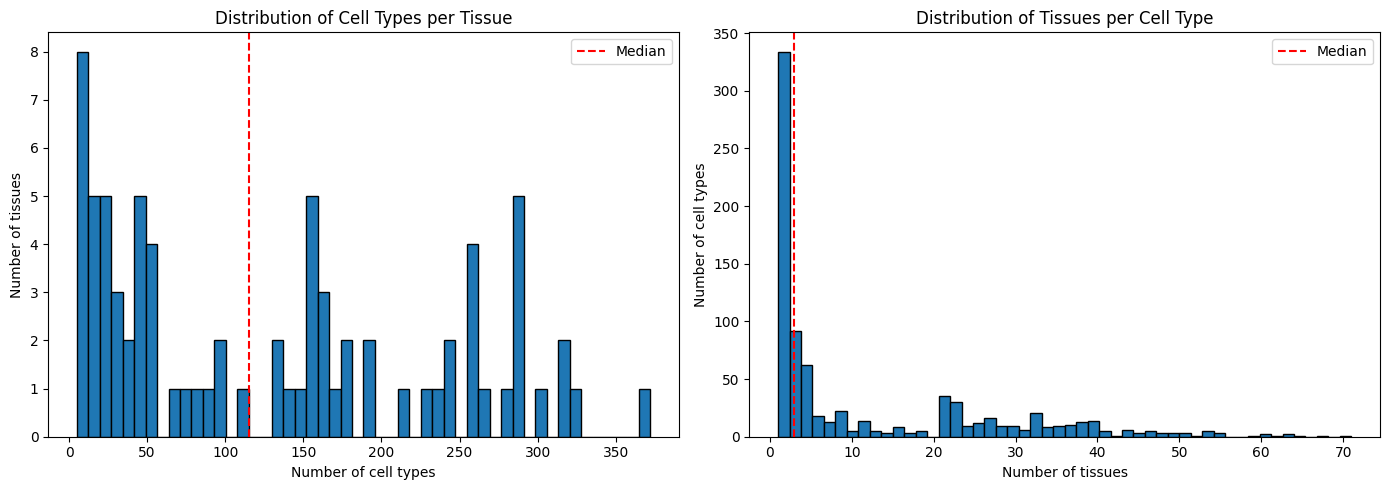


Statistics:
  Cell types per tissue: median=115, mean=130.7
  Tissues per cell type: median=3, mean=12.1


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of cell types per tissue
celltypes_per_tissue = [len(v) for v in tissue_celltype_counts.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(celltypes_per_tissue, bins=50, edgecolor='black')
axes[0].set_xlabel('Number of cell types')
axes[0].set_ylabel('Number of tissues')
axes[0].set_title('Distribution of Cell Types per Tissue')
axes[0].axvline(np.median(celltypes_per_tissue), color='red', linestyle='--', label='Median')
axes[0].legend()

# Tissues per cell type
tissues_per_celltype = defaultdict(int)
for tissue_data in tissue_celltype_counts.values():
    for cell_type in tissue_data.keys():
        tissues_per_celltype[cell_type] += 1

axes[1].hist(list(tissues_per_celltype.values()), bins=50, edgecolor='black')
axes[1].set_xlabel('Number of tissues')
axes[1].set_ylabel('Number of cell types')
axes[1].set_title('Distribution of Tissues per Cell Type')
axes[1].axvline(np.median(list(tissues_per_celltype.values())), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / "cooccurrence_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistics:")
print(f"  Cell types per tissue: median={np.median(celltypes_per_tissue):.0f}, mean={np.mean(celltypes_per_tissue):.1f}")
print(f"  Tissues per cell type: median={np.median(list(tissues_per_celltype.values())):.0f}, mean={np.mean(list(tissues_per_celltype.values())):.1f}")

Heatmap matrix shape: (77, 832) (tissues x cell_types)
Non-zero entries: 4,283 / 64,064

Clustering tissues...
Clustering cell types...
Reordered heatmap matrix shape: (77, 832)


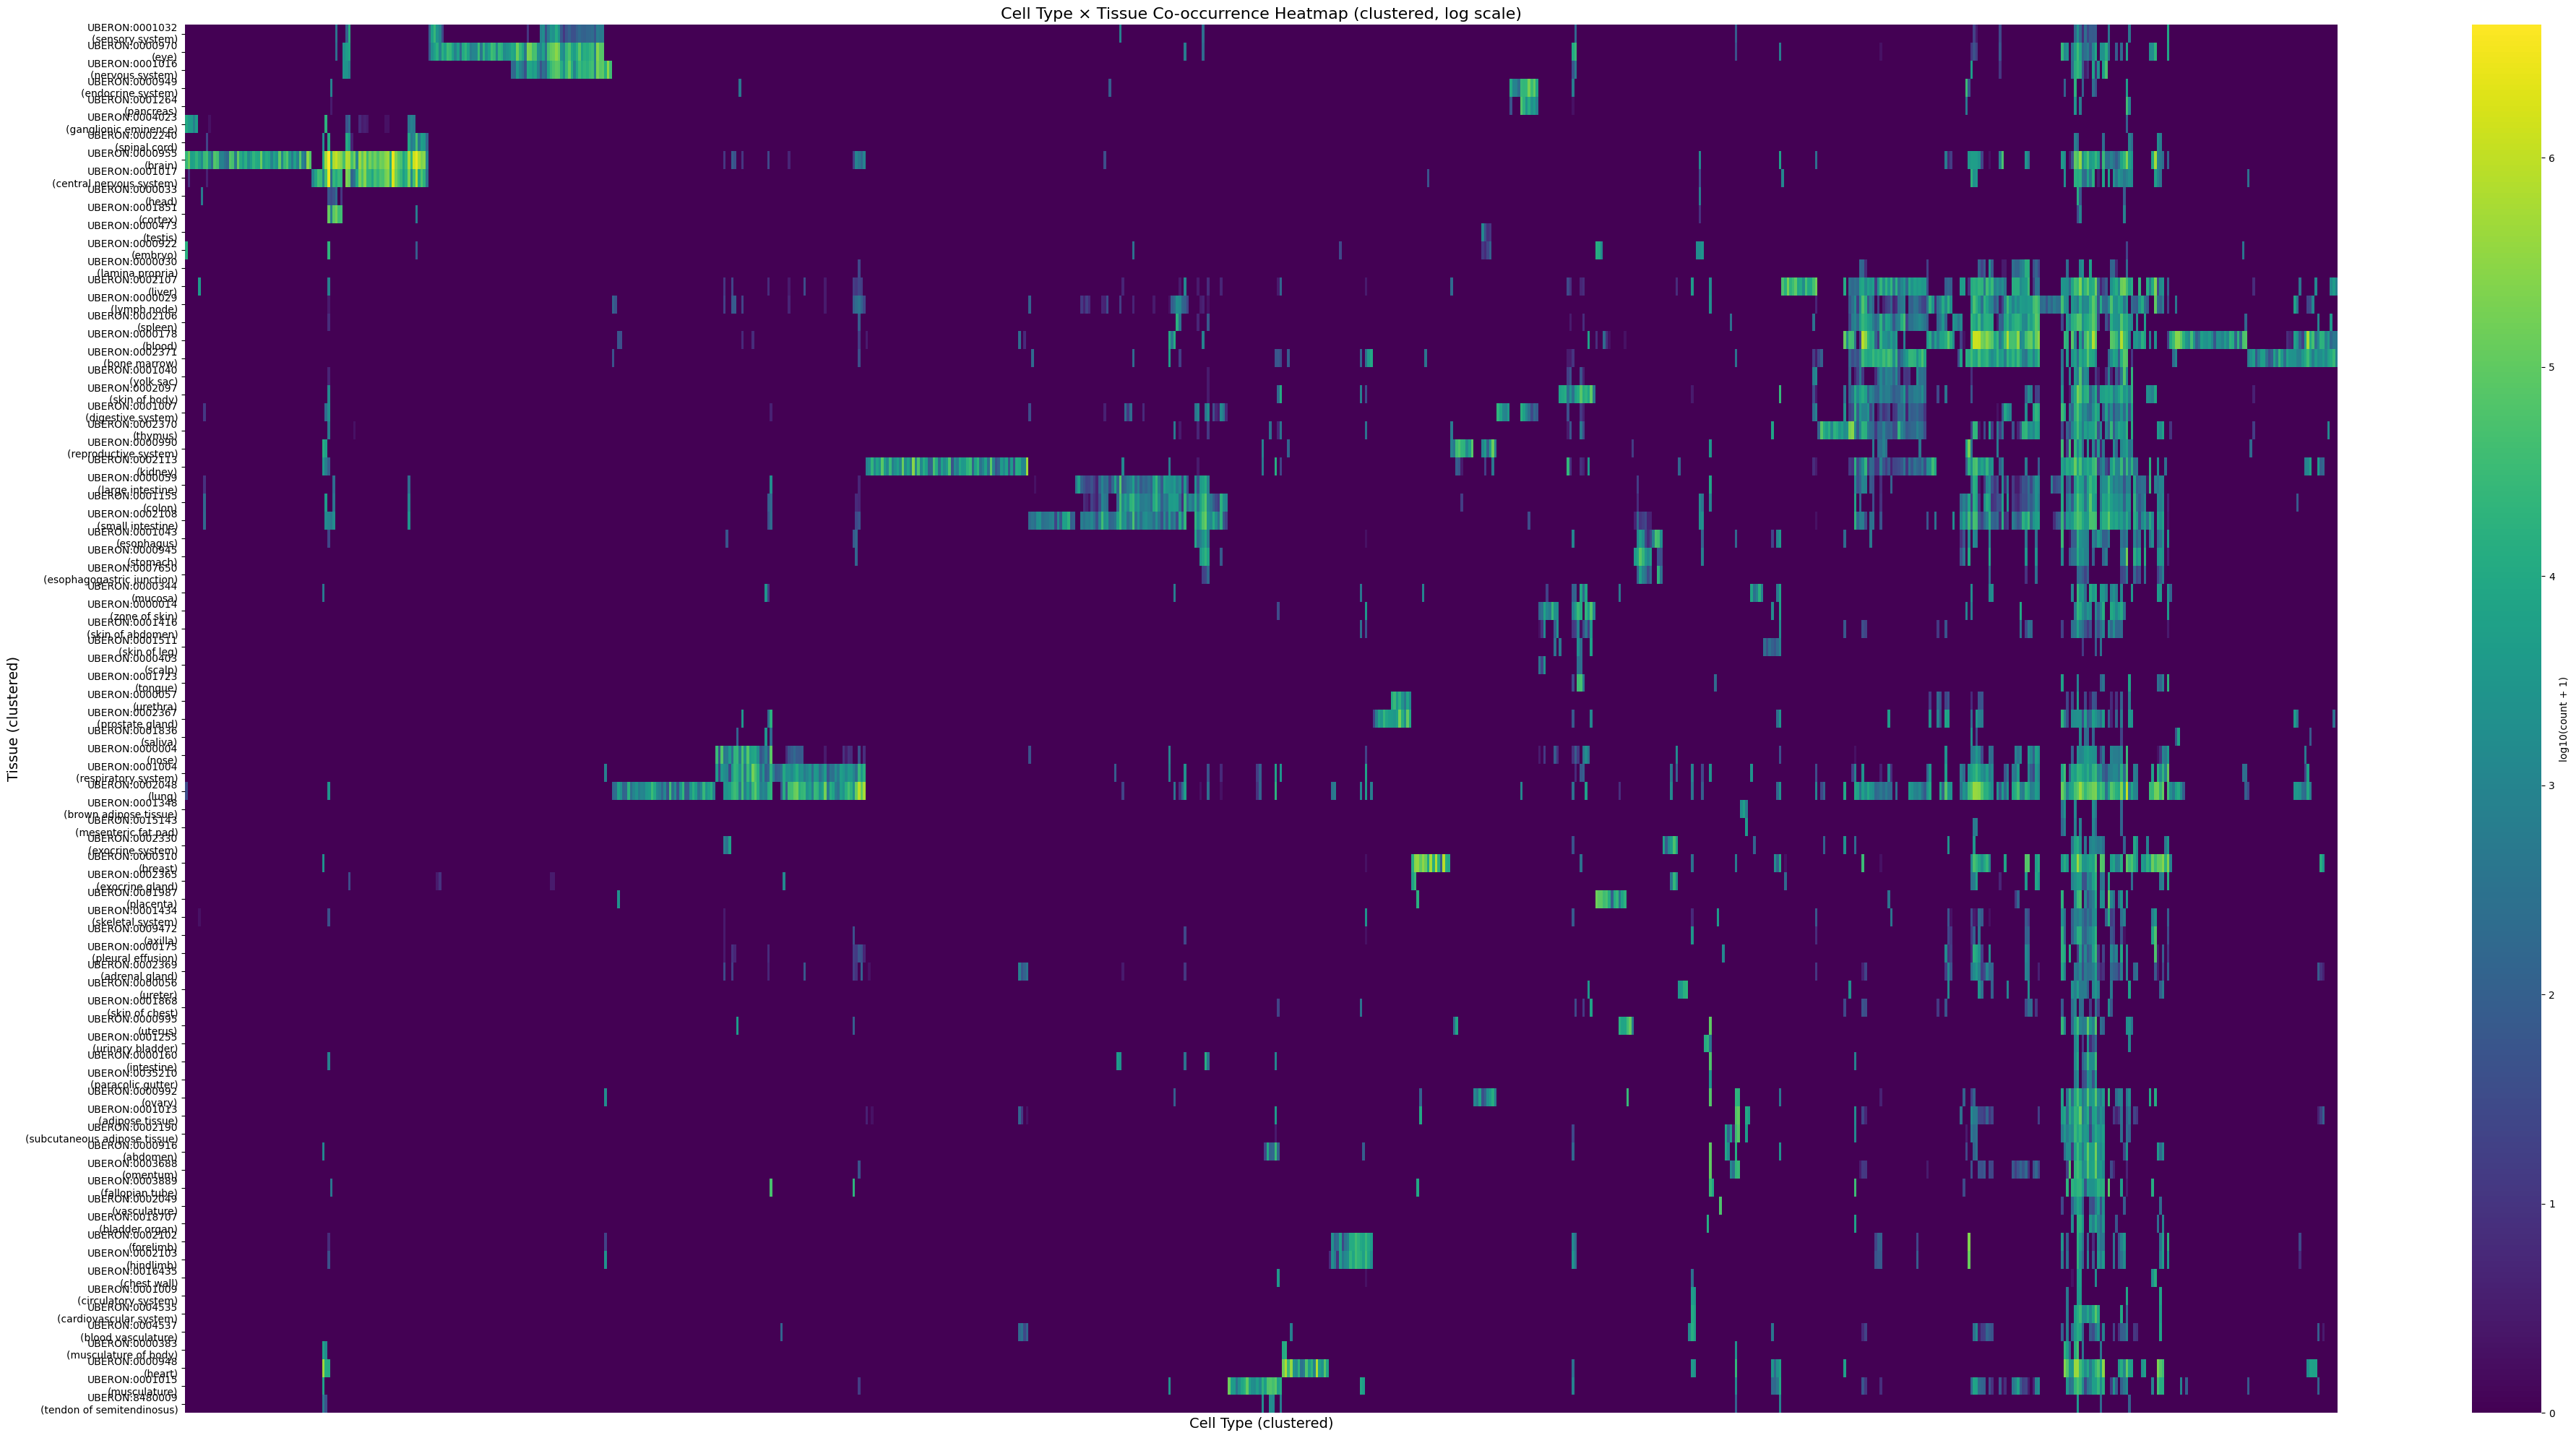


Saved clustered heatmap to: /data/GenePT-tools/data/cellxgene_constraints/tissue_celltype_heatmap_full.png


In [57]:
## 8. Create Heatmap: Cell Type (x) vs Tissue (y)

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Convert nested dict to DataFrame for heatmap
# Use tissue labels for better readability in visualization
tissue_list = sorted(tissue_celltype_counts.keys())
celltype_list = sorted(all_cell_types)

# Create matrix: rows = tissues, columns = cell types
heatmap_data = []
tissue_labels = []  # Store human-readable labels
for tissue_id in tissue_list:
  tissue_label = tissue_id_to_label[tissue_id]
  tissue_labels.append(f"{tissue_id}\n({tissue_label})")
  row = []
  for cell_type in celltype_list:
    count = tissue_celltype_counts[tissue_id].get(cell_type, 0)
    row.append(count)
  heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=tissue_labels, columns=celltype_list)

print(f"Heatmap matrix shape: {heatmap_df.shape} (tissues x cell_types)")
print(f"Non-zero entries: {(heatmap_df > 0).sum().sum():,} / {heatmap_df.size:,}")

# Cluster tissues (rows) based on their cell type profiles
print("\nClustering tissues...")
# Use log-transformed data for clustering to reduce impact of very large counts
log_df = np.log10(heatmap_df + 1)
# Compute pairwise distances between tissues (rows)
tissue_distances = pdist(log_df.values, metric='cosine')  # Cosine distance works well for count data
tissue_linkage = linkage(tissue_distances, method='ward')
tissue_order = leaves_list(tissue_linkage)

# Cluster cell types (columns) based on their tissue profiles
print("Clustering cell types...")
# Transpose to cluster columns
celltype_distances = pdist(log_df.T.values, metric='cosine')
celltype_linkage = linkage(celltype_distances, method='ward')
celltype_order = leaves_list(celltype_linkage)

# Reorder DataFrame based on clustering
heatmap_df_clustered = heatmap_df.iloc[tissue_order, celltype_order]

print(f"Reordered heatmap matrix shape: {heatmap_df_clustered.shape}")

# Create heatmap with log scale for better visualization
fig, ax = plt.subplots(figsize=(40, 20))

# Use log scale + 1 to handle zeros
log_data = np.log10(heatmap_df_clustered + 1)

sns.heatmap(
  log_data,
  cmap='viridis',
  cbar_kws={'label': 'log10(count + 1)'},
  xticklabels=False,  # Too many cell types to show labels
  yticklabels=True,    # Show tissue labels
  ax=ax
)

ax.set_xlabel('Cell Type (clustered)', fontsize=14)
ax.set_ylabel('Tissue (clustered)', fontsize=14)
ax.set_title('Cell Type × Tissue Co-occurrence Heatmap (clustered, log scale)', fontsize=16)

plt.tight_layout()
plt.savefig(output_dir / "tissue_celltype_heatmap_full.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved clustered heatmap to: {output_dir / 'tissue_celltype_heatmap_full.png'}")



Clustering filtered tissues and cell types...


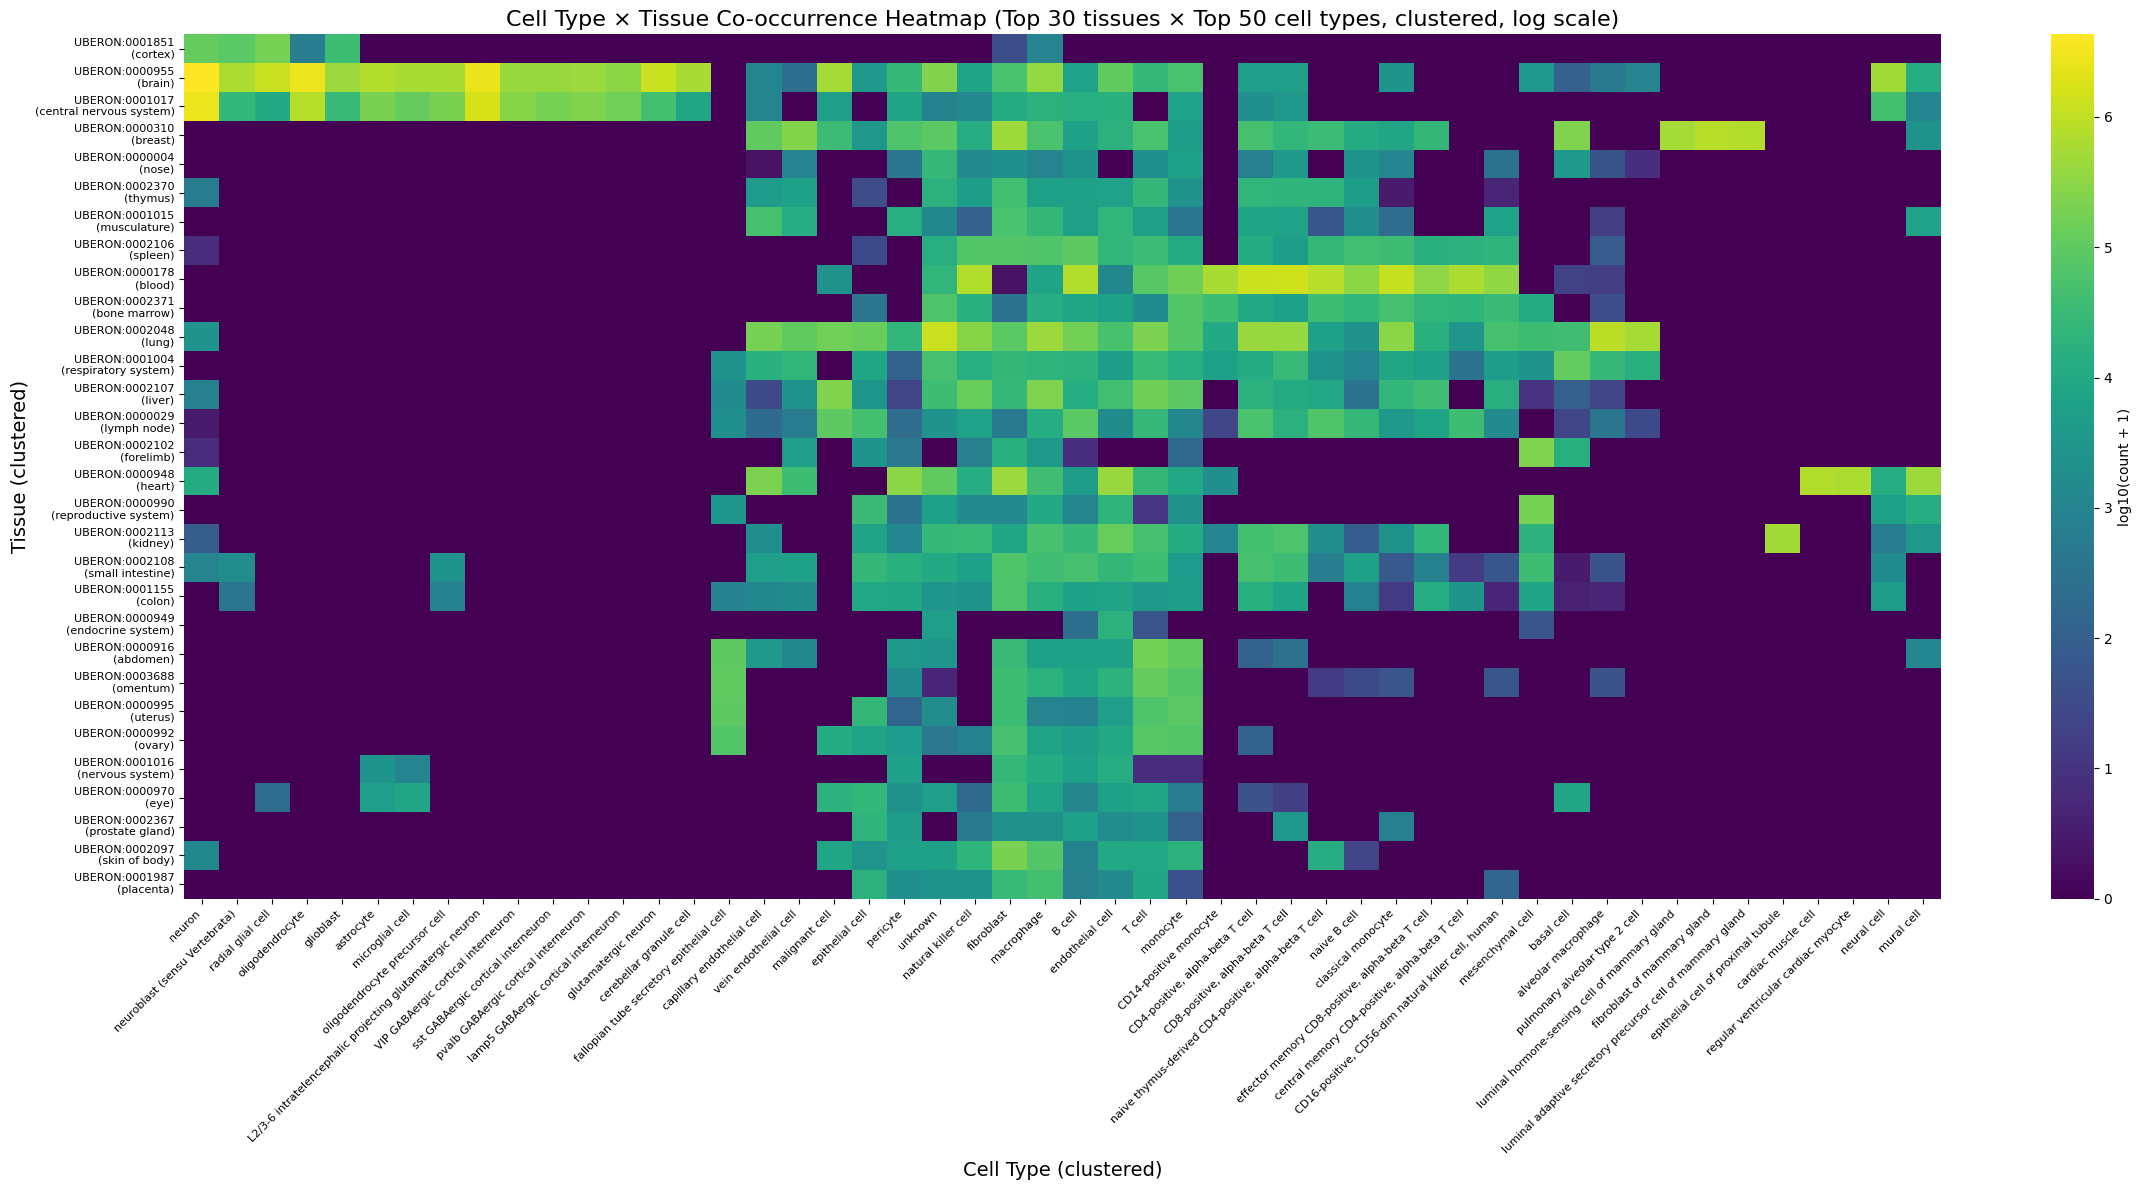


Saved clustered filtered heatmap to: /data/GenePT-tools/data/cellxgene_constraints/tissue_celltype_heatmap_top_filtered.png


In [58]:
# Create a filtered heatmap with top N tissues and top M cell types for better readability
top_n_tissues = 30
top_m_celltypes = 50

# Get top tissues by total cell count
tissue_totals = {tissue_id: sum(cell_types.values()) for tissue_id, cell_types in tissue_celltype_counts.items()}
top_tissues = sorted(tissue_totals.items(), key=lambda x: x[1], reverse=True)[:top_n_tissues]
top_tissue_ids = [t[0] for t in top_tissues]
top_tissue_labels = [f"{t[0]}\n({tissue_id_to_label[t[0]]})" for t in top_tissues]

# Get top cell types by total count across all tissues
celltype_totals = defaultdict(int)
for tissue_data in tissue_celltype_counts.values():
  for cell_type, count in tissue_data.items():
    celltype_totals[cell_type] += count
top_celltypes = sorted(celltype_totals.items(), key=lambda x: x[1], reverse=True)[:top_m_celltypes]
top_celltype_names = [c[0] for c in top_celltypes]

# Create filtered matrix
filtered_data = []
for tissue_id in top_tissue_ids:
  row = []
  for cell_type in top_celltype_names:
    count = tissue_celltype_counts[tissue_id].get(cell_type, 0)
    row.append(count)
  filtered_data.append(row)

filtered_df = pd.DataFrame(filtered_data, index=top_tissue_labels, columns=top_celltype_names)

# Cluster the filtered data
print("\nClustering filtered tissues and cell types...")
log_filtered = np.log10(filtered_df + 1)

# Cluster tissues (rows)
tissue_distances_filtered = pdist(log_filtered.values, metric='cosine')
tissue_linkage_filtered = linkage(tissue_distances_filtered, method='ward')
tissue_order_filtered = leaves_list(tissue_linkage_filtered)

# Cluster cell types (columns)
celltype_distances_filtered = pdist(log_filtered.T.values, metric='cosine')
celltype_linkage_filtered = linkage(celltype_distances_filtered, method='ward')
celltype_order_filtered = leaves_list(celltype_linkage_filtered)

# Reorder filtered DataFrame
filtered_df_clustered = filtered_df.iloc[tissue_order_filtered, celltype_order_filtered]

# Create filtered heatmap
fig, ax = plt.subplots(figsize=(24, 12))

log_filtered_clustered = np.log10(filtered_df_clustered + 1)

sns.heatmap(
  log_filtered_clustered,
  cmap='viridis',
  cbar_kws={'label': 'log10(count + 1)'},
  xticklabels=True,
  yticklabels=True,
  ax=ax,
  fmt='.1f'
)

ax.set_xlabel('Cell Type (clustered)', fontsize=14)
ax.set_ylabel('Tissue (clustered)', fontsize=14)
ax.set_title(f'Cell Type × Tissue Co-occurrence Heatmap (Top {top_n_tissues} tissues × Top {top_m_celltypes} cell types, clustered, log scale)', fontsize=16)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "tissue_celltype_heatmap_top_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved clustered filtered heatmap to: {output_dir / 'tissue_celltype_heatmap_top_filtered.png'}")


## Summary

This notebook has created:

1. **`tissue_celltype_counts.json`**: Human-readable counts with tissue labels
2. **`tissue_celltype_counts.pt`**: PyTorch tensors with:
   - `tissue_vocab`: List of curated tissue ontology IDs (81 tissues)
   - `tissue_id_to_label`: Mapping from tissue ID to human-readable name
   - `celltype_vocab`: List of cell type names
   - `tissue_to_counts`: Dict mapping tissue ID to count vector `[C]`

**Tissue mapping:** All CellxGene tissues mapped to 81 curated tissues using:
- Direct match (Tier 1)
- UBERON ontology ancestor lookup (Tier 2)  
- Manual fallback mappings (Tier 3)

These files can be used to build:
- **Allowlists**: Filter by `counts >= min_count`
- **Soft priors**: `log P(celltype | tissue)` via Laplace smoothing